# Laboratorio 8 - DuckDB

Análisis reproducible NYC TLC. Ejecute primero `scripts/run_pipeline.py`. Los datos originales permanecen en Parquet. El informe y las reglas de calidad están en `docs/`.

In [1]:
from pathlib import Path
import sys
ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'scripts'))
from common import connect, create_views, query
import pandas as pd
from IPython.display import display, Image
con = connect()
create_views(con)

## Ejercicio 3: archivos, filas, columnas y muestra

In [2]:
display(con.sql(query('01_inventory.sql')).df())
display(con.sql('DESCRIBE trips_raw').df())
display(con.sql(query('02_sample.sql')).df())

,taxi,source_year,files,rows,earliest_pickup,latest_pickup
0,green,2024,12,660218,2008-12-31 00:00:00,2025-01-01 22:21:15
1,green,2025,12,591375,2008-12-31 15:13:04,2026-01-01 21:09:39
2,green,2026,8,337114,2008-12-31 17:35:31,2026-08-31 23:58:28
3,yellow,2024,12,41169720,2002-12-31 16:46:07,2026-06-26 23:53:12
4,yellow,2025,12,48722602,2007-12-05 18:45:00,2025-12-31 23:59:59
5,yellow,2026,8,29703355,2001-01-01 09:23:58,2026-08-31 23:59:59


,column_name,column_type,null,key,default,extra
0,taxi,VARCHAR,YES,None,None,None
1,source_year,INTEGER,YES,None,None,None
2,source_month,INTEGER,YES,None,None,None
3,source_file,VARCHAR,YES,None,None,None
4,vendor_id,BIGINT,YES,None,None,None
5,pickup,TIMESTAMP,YES,None,None,None
6,dropoff,TIMESTAMP,YES,None,None,None
7,passenger_count,DOUBLE,YES,None,None,None
8,trip_distance,DOUBLE,YES,None,None,None
9,pu_location_id,INTEGER,YES,None,None,None


,taxi,source_year,source_month,source_file,vendor_id,pickup,dropoff,passenger_count,trip_distance,pu_location_id,do_location_id,payment_type,ratecode_id,fare_amount,tip_amount,total_amount,tolls_amount,congestion_surcharge,cbd_congestion_fee
0,yellow,2024,1,/Users/javiervalladares/Library/Mobile Documen...,2,2024-01-01 00:57:55,2024-01-01 01:17:43,1.0,1.72,186,79,2,1.0,17.7,0.00,22.70,0.0,2.50,NaN
1,yellow,2024,1,/Users/javiervalladares/Library/Mobile Documen...,1,2024-01-01 00:03:00,2024-01-01 00:09:36,1.0,1.80,140,236,1,1.0,10.0,3.75,18.75,0.0,2.50,NaN
2,yellow,2024,1,/Users/javiervalladares/Library/Mobile Documen...,1,2024-01-01 00:17:06,2024-01-01 00:35:01,1.0,4.70,236,79,1,1.0,23.3,3.00,31.30,0.0,2.50,NaN
3,yellow,2024,1,/Users/javiervalladares/Library/Mobile Documen...,1,2024-01-01 00:36:38,2024-01-01 00:44:56,1.0,1.40,79,211,1,1.0,10.0,2.00,17.00,0.0,2.50,NaN
4,yellow,2024,1,/Users/javiervalladares/Library/Mobile Documen...,1,2024-01-01 00:46:51,2024-01-01 00:52:57,1.0,0.80,211,148,1,1.0,7.9,3.20,16.10,0.0,2.50,NaN
5,yellow,2024,1,/Users/javiervalladares/Library/Mobile Documen...,1,2024-01-01 00:54:08,2024-01-01 01:26:31,1.0,4.70,148,141,1,1.0,29.6,6.90,41.50,0.0,2.50,NaN
6,yellow,2024,1,/Users/javiervalladares/Library/Mobile Documen...,2,2024-01-01 00:49:44,2024-01-01 01:15:47,2.0,10.82,138,181,1,1.0,45.7,10.00,64.95,0.0,0.00,NaN
7,yellow,2024,1,/Users/javiervalladares/Library/Mobile Documen...,1,2024-01-01 00:30:40,2024-01-01 00:58:40,0.0,3.00,246,231,2,1.0,25.4,0.00,30.40,0.0,2.50,NaN
8,yellow,2024,1,/Users/javiervalladares/Library/Mobile Documen...,2,2024-01-01 00:26:01,2024-01-01 00:54:12,1.0,5.44,161,261,2,1.0,31.0,0.00,36.00,0.0,2.50,NaN
9,yellow,2024,1,/Users/javiervalladares/Library/Mobile Documen...,2,2024-01-01 00:28:08,2024-01-01 00:29:16,1.0,0.04,113,113,2,1.0,3.0,0.00,8.00,0.0,2.50,NaN


## Calidad de datos
Los motivos se solapan; `excluded` es la unión. Las filas originales se conservan.

In [3]:
display(con.sql(query('03_quality.sql')).df())

,taxi,source_year,rows,bad_date,bad_distance,bad_duration,bad_amount,missing_passengers,unusual_passengers,excluded,excluded_pct
0,green,2024,660218,164,34809,3641,2667,24328,6941,39512,5.985
1,green,2025,591375,248,24647,4617,5000,49880,8477,32964,5.574
2,green,2026,337114,98,12284,1521,6196,48775,4626,19300,5.725
3,yellow,2024,41169720,420,777918,38859,748345,4091232,401638,1491879,3.624
4,yellow,2025,48722602,214,1405828,564705,2870701,11611894,260208,4570673,9.381
5,yellow,2026,29703355,146,953454,381810,180386,7716688,91387,1484005,4.996


## Ejercicios 4, 7 y 8: indicadores y evolución
Las 13 preguntas justificadas están en `docs/metodologia.md`. La comparación anual usa meses comunes, pues 2026 es parcial.

In [4]:
monthly = con.sql(query('04_monthly.sql')).df()
display(monthly.head(12))
display(con.sql(query('08_common_months.sql')).df())

,taxi,year,month,period,trips,total_usd,avg_total_usd,median_miles,median_minutes,credit_pct,card_tip_pct
0,green,2024,1,2024-01-01,53277,1180287.29,22.154,1.88,11.433,64.758,21.144
1,green,2024,2,2024-02-01,50375,1131082.36,22.453,1.89,11.450,65.941,20.926
2,green,2024,3,2024-03-01,54069,1228381.67,22.719,1.88,11.650,66.215,20.897
3,green,2024,4,2024-04-01,52914,1232111.09,23.285,1.92,11.700,68.904,21.005
4,green,2024,5,2024-05-01,57424,1404590.25,24.460,1.98,12.417,69.205,20.551
5,green,2024,6,2024-06-01,51649,1279349.30,24.770,2.02,12.250,69.053,20.287
6,green,2024,7,2024-07-01,48447,1182175.27,24.401,2.04,11.783,69.082,20.463
7,green,2024,8,2024-08-01,48623,1255072.84,25.812,2.10,12.000,69.340,19.930
8,green,2024,9,2024-09-01,51205,1356612.74,26.494,2.08,12.733,70.493,19.807
9,green,2024,10,2024-10-01,53135,1326208.15,24.959,2.00,12.350,70.981,20.422


,taxi,year,trips,months,total_usd,avg_total_usd,avg_miles,avg_minutes,credit_pct,avg_cbd_fee_usd
0,green,2024,416778,8,9.893050e+06,23.737,2.912,14.418,67.798,NaN
1,green,2025,374124,8,9.289908e+06,24.831,3.095,15.251,69.761,0.074
2,green,2026,317814,8,8.055536e+06,25.347,3.293,16.852,66.576,0.063
3,yellow,2024,25492745,8,7.220755e+08,28.325,3.422,16.387,75.939,NaN
4,yellow,2025,28683362,8,8.140550e+08,28.381,3.451,16.456,68.729,0.547
5,yellow,2026,28219350,8,8.534201e+08,30.242,3.515,17.661,65.397,0.543


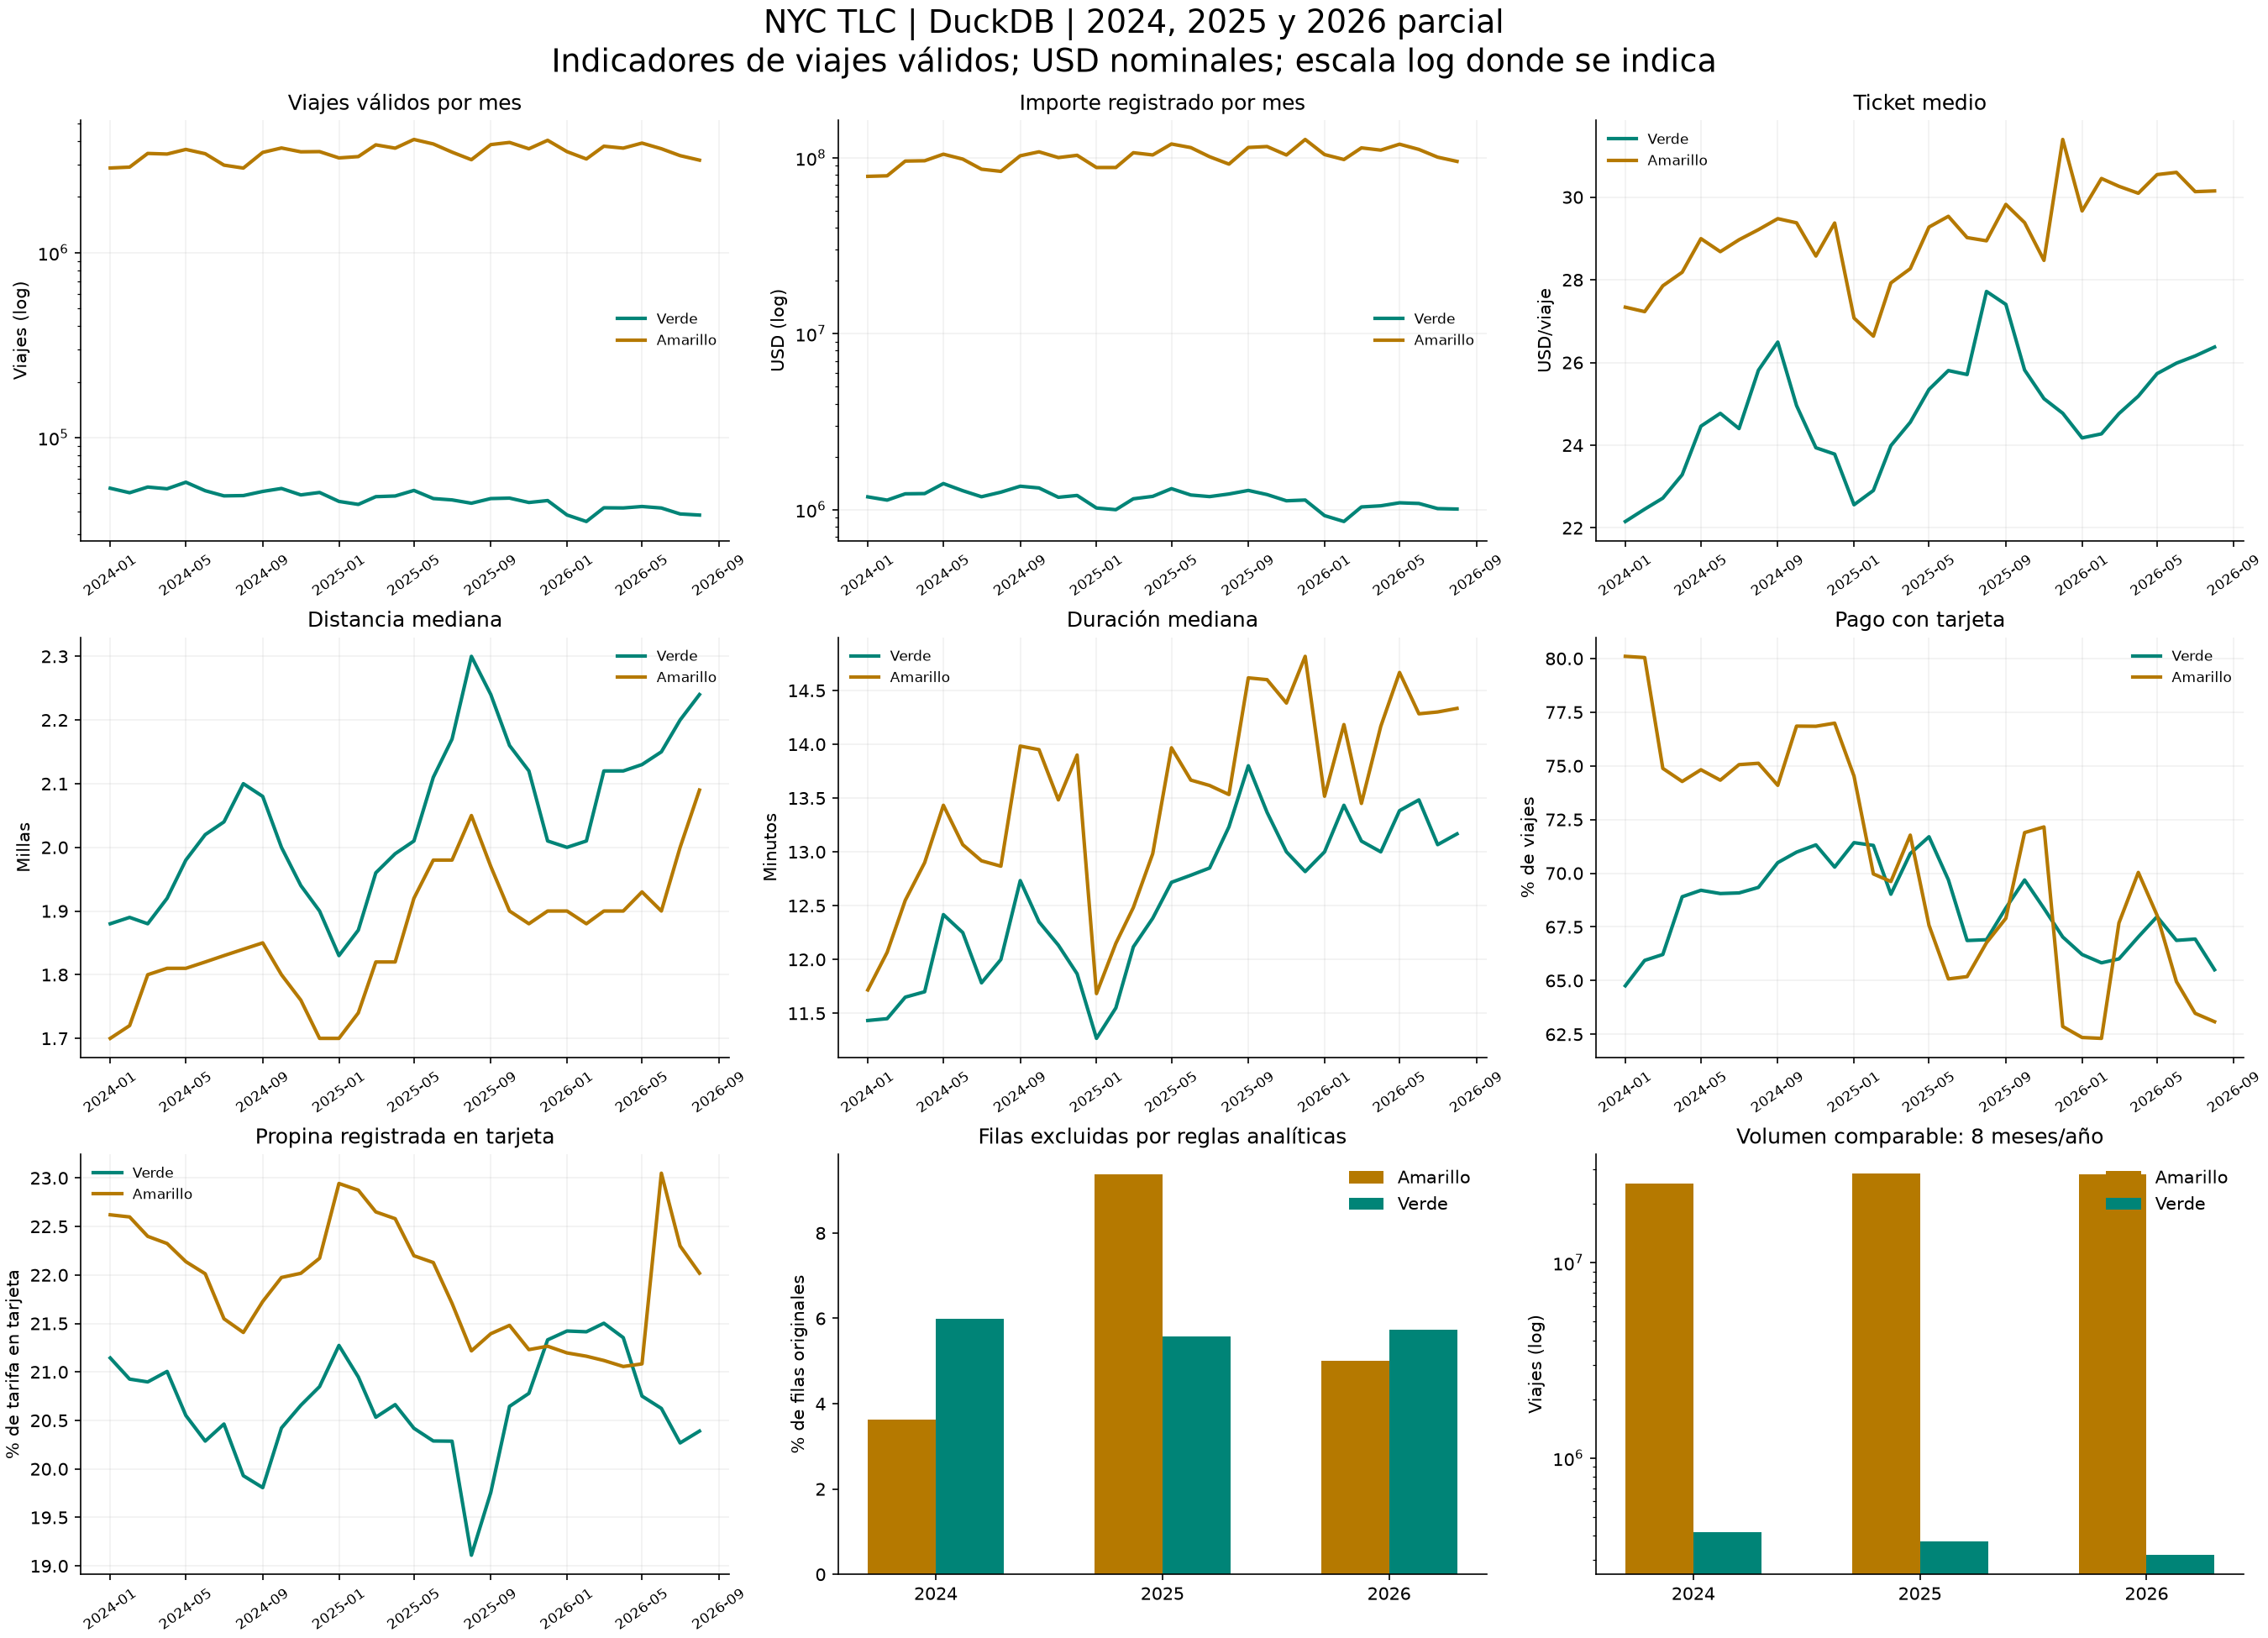

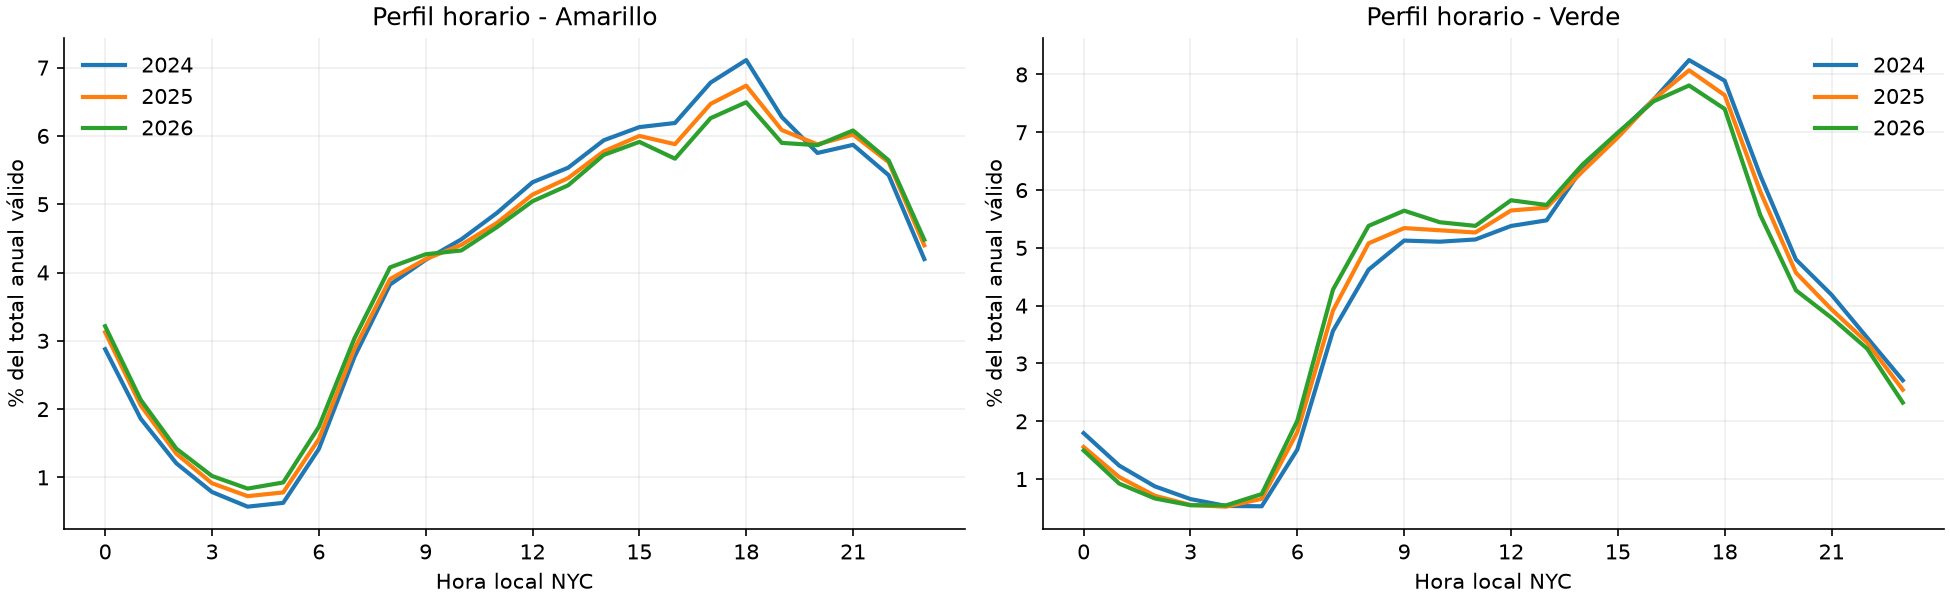

In [5]:
display(Image(filename=str(ROOT / 'docs/figures/indicadores.png')))
display(Image(filename=str(ROOT / 'docs/figures/perfil_horario.png')))

## Ejercicio 6: benchmark medido
Misma proyección y SQL, caché caliente, tres repeticiones. Resultados equivalentes verificados en cada repetición. CTAS reportado aparte.

In [6]:
display(pd.read_csv(ROOT / 'docs/benchmarks/materialization.csv'))
display(pd.read_csv(ROOT / 'docs/benchmarks/summary.csv'))

,scale,files,rows,materialization_seconds,database_bytes,parquet_bytes
0,2026_one_month,2,3765161,1.075714,96743424,65156736
1,2026,16,30040469,7.860673,775696384,519727000
2,2024_2026,40,71870407,18.199607,1826893824,1228648745
3,2024_2025_2026,64,121184384,30.891018,3110088704,2073081961


,scale,files,rows,query,mode,median,min,max
0,2026_one_month,2,3765161,distribution,parquet,0.122562,0.116477,0.123031
1,2026_one_month,2,3765161,distribution,duckdb,0.119857,0.114391,0.182281
2,2026_one_month,2,3765161,hourly,parquet,0.037763,0.036831,0.038076
3,2026_one_month,2,3765161,hourly,duckdb,0.022176,0.021888,0.023453
4,2026_one_month,2,3765161,monthly,parquet,0.019978,0.019782,0.021685
5,2026_one_month,2,3765161,monthly,duckdb,0.023333,0.022558,0.025093
6,2026_one_month,2,3765161,top_zones,parquet,0.026753,0.026682,0.027878
7,2026_one_month,2,3765161,top_zones,duckdb,0.022800,0.020936,0.022899
8,2026,16,30040469,distribution,parquet,1.435691,1.221626,2.080042
9,2026,16,30040469,distribution,duckdb,1.070615,1.054355,1.380376


## Discusión
Consulte `docs/informe.md` para los hallazgos numéricos y respuestas 9.1 a 9.8. El tablero interactivo se reconstruye con `scripts/setup_metabase.py`.

In [7]:
con.close()